<a href="https://colab.research.google.com/github/saranya0207/Project2_DataScience/blob/main/DataScience_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Palm Oil Prices in Malaysia Using ARIMA and LSTM Model
---

## Abstract

Palm oil is one of Malaysia's most important commodities, contributing significantly to the national economy as the country is one of the largest producers and exporters globally. The price of palm oil is highly volatile, thus making accurate forecasting is essential for to ensure that theing industry is stableility and supporting economic growth. This study aims to forecast palm oil prices in Malaysia using Autoregressive Integrated Moving Average (ARIMA) and Long Short-Term Memory (LSTM) models. Monthly closing price data for palm oil from January 2012 to Dec 2023 were used to construct the forecasting models. The performance of both models was evaluated using Root Mean Square Error (RMSE) and Mean Absolute Percentage Error (MAPE). Rolling forecasting was used as an iterative method to improve the accuracy of both models, enhancing their ability to predict palm oil price trends. The results show that LSTM model outperformed ARIMA model, particularly in capturing sharp price fluctuations and complex patterns. LSTM achieved lower RMSE and MAPE values compared to ARIMA, showing its better performance in handling volatile price changes. The findings of this study can provide useful insights for plantation companies, traders, and policymakers to improve risk management strategies, plan production more effectively and make better decisions in response to fluctuation ofng palm oil prices.

## 1. Introduction

A commodity is a physical product that can be traded in commodity markets, such as gold, oil, coffee, corn, and sugar. Palm oil is one of Malaysia’s major commodities and plays an important role in global trade. Introduced to Malaysia in the 1870s and commercially cultivated since 1917, Malaysia has become one of the world’s largest palm oil producers.

Palm oil is the most productive vegetable oil, yielding about 4.5 tonnes per hectare, which is higher than other vegetable oils such as soybean and sunflower oil. The industry is a significant contributor to Malaysia’s economy, generating export revenue of RM65 billion and contributing 3.5% to the country’s GDP in 2019 (Yee & Samsudin, 2021).

Malaysia exports palm oil to many countries, with India, China, and the European Union among its largest markets. Demand for palm oil continues to grow due to global economic recovery, population growth, and increasing biodiesel usage. At the same time, supply constraints in other producing countries have strengthened the position of Malaysian palm oil in the global market.

Given the continuous fluctuations in palm oil prices, accurate forecasting is important for decision-making. This study uses daily palm oil price data to compare two forecasting models: Autoregressive Integrated Moving Average (ARIMA) and Long Short-Term Memory (LSTM). ARIMA is a traditional time series forecasting model suitable for linear data, while LSTM is a machine learning model capable of capturing complex and non-linear patterns. The objective of this study is to evaluate and compare the forecasting performance of both models and determine which model provides more accurate palm oil price predictions.

## 2. Problem Statement
Palm oil prices are highly volatile and are influenced by various factors, including global supply and demand, crude oil prices, soybean oil prices as a substitute product, exchange rates, and global economic conditions (Hamid & Shabri, 2019). In addition, market uncertainty, trade policies, geopolitical conflicts, and weather conditions can significantly affect palm oil price movements.

Over the past few years, palm oil prices have experienced substantial fluctuations. Prices increased sharply in 2022 due to disruptions in the global vegetable oil supply chain before declining as supply conditions improved. As of 2026, the palm oil market continues to face uncertainty driven by changes in biodiesel demand, weather-related production risks, and global economic developments. These factors make palm oil prices difficult to predict accurately.

The volatility of palm oil prices affects the income of plantation owners, traders, manufacturers, investors, and the country's export revenue. Therefore, accurate price forecasting is essential to support effective decision-making among stakeholders. This study evaluates the performance of the Autoregressive Integrated Moving Average (ARIMA) model and the Long Short-Term Memory (LSTM) model in forecasting palm oil prices. A comparison of these models is conducted to identify the approach that provides more accurate forecasts based on lower prediction errors.

## 3. Objectives
This study consists of the following objectives:

1. To forecast palm oil prices in Malaysia using the Autoregressive Integrated Moving Average (ARIMA) model and the Long Short-Term Memory (LSTM) model.

2. To compare the forecasting performance of the ARIMA and LSTM models using Mean Absolute Percentage Error (MAPE) and Root Mean Square Error (RMSE).

## 4. Literature Review

### 4.1 Palm Oil Market

Palm oil is one of the most important agricultural commodities in Malaysia and contributes significantly to the country's export earnings. The price of palm oil is influenced by factors such as global supply and demand, crude oil prices, exchange rates, weather conditions, and government policies. Due to these factors, palm oil prices often fluctuate, creating uncertainty for producers, traders, and investors. According to Isa et al. (2020), macroeconomic factors such as inflation, gross domestic product (GDP), and exchange rates significantly affect palm oil prices in Malaysia.

### 4.2 ARIMA Model

The Autoregressive Integrated Moving Average (ARIMA) model is a widely used statistical method for time series forecasting. It utilizes historical observations to identify patterns and generate future forecasts. ARIMA is particularly suitable for linear time series data and has been widely applied in commodity price forecasting. Azme et al. (2018) used ARIMA, ARCH, and GARCH models to forecast Malaysian palm oil prices and found that the ARIMA(2,1,5) model provided the best forecasting performance based on the Akaike Information Criterion (AIC) and Hannan-Quinn criterion.

### 4.3 LSTM Model

Long Short-Term Memory (LSTM) is a deep learning model developed to overcome the limitations of traditional Recurrent Neural Networks (RNNs) in learning long-term dependencies. LSTM is capable of capturing complex and non-linear patterns in time series data, making it suitable for forecasting volatile commodity prices. Amal (2021) applied an LSTM model to forecast crude palm oil prices and achieved a Mean Absolute Percentage Error (MAPE) of 2.11%, demonstrating the model's ability to produce highly accurate forecasts.

### 4.4 Comparison of Previous Studies

Previous studies suggest that both ARIMA and LSTM are effective forecasting models, but their performance depends on the characteristics of the data. ARIMA performs well for linear and relatively stable time series, while LSTM is more effective in capturing complex and non-linear relationships. Siami-Namini et al. (2018) compared ARIMA and LSTM models and concluded that LSTM achieved higher forecasting accuracy than ARIMA for time series prediction tasks. Therefore, comparing these two models for palm oil price forecasting is important to determine the most suitable approach.

## 5. Methodology

### 5.1 Data

The data used in this study consist of monthly palm oil closing prices in Malaysia obtained from Investing.com. The dataset covers from January 2015 to June 2026, comprising a total of 125 observations. The dataset is split chronologically into **80% training data** and **20% testing data**.

> **Note:** Update the `file_path` variable below to point to your own CSV file in Google Drive. The CSV is expected to have at least two columns: `Date` and `Price`.

### 5.2 Setup

In [1]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 21.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm
import os
import random
import tensorflow as tf


from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 1. Set Python hash seed
os.environ['PYTHONHASHSEED'] = '42'

# 2. Python random
random.seed(42)

# 3. NumPy
np.random.seed(42)

# 4. TensorFlow
tf.random.set_seed(42)

In [3]:
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # forces CPU only (most stable)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 5.3 Loading and Cleaning the Data

The raw `Price` column from Investing.com is stored as text with thousands separators (commas), so it must be converted to a numeric type. The data is also sorted in chronological order (oldest to newest) and the `Date` column is set as the index, which is required for time-series modelling.

In [5]:
# Read data
file_path = '/content/drive/MyDrive/Data Science/price.csv'
data = pd.read_csv(file_path)

# Keep only the Date and Price columns
data = data[['Date', 'Price']]

# Parse the Date column (adjust the format string if your dates are formatted differently)
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')

# Remove thousands separators from Price and convert to float
data['Price'] = data['Price'].astype(str).str.replace(',', '', regex=False).astype(float)

# Sort chronologically (oldest to newest)
data = data.sort_values('Date')

# Set Date as the index
data.set_index('Date', inplace=True)

data.head()

,Price
Date,
2012-01-01,3075.0
2012-02-01,3225.0
2012-03-01,3480.0
2012-04-01,3472.0
2012-05-01,3070.0


### 5.4 Train-Test Split

Following the methodology, the data is split chronologically: the first **80%** of observations form the training set, and the remaining **20%** form the test set used to evaluate forecast accuracy.

In [6]:
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print('Training set:', train_data.shape)
print('Test set:', test_data.shape)
print()
print(train_data.head())
print()
print(test_data.head())

Training set: (115, 1)
Test set: (29, 1)

             Price
Date              
2012-01-01  3075.0
2012-02-01  3225.0
2012-03-01  3480.0
2012-04-01  3472.0
2012-05-01  3070.0

             Price
Date              
2021-08-01  4500.0
2021-09-01  4833.0
2021-10-01  5402.0
2021-11-01  5188.0
2021-12-01  5159.0


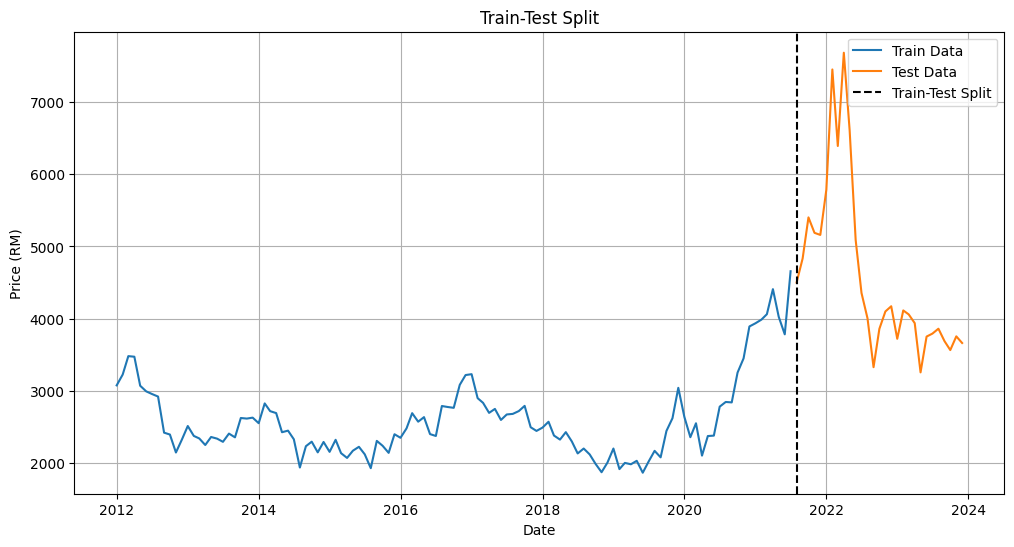

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(train_data.index, train_data['Price'], label='Train Data')
plt.plot(test_data.index, test_data['Price'], label='Test Data')

plt.axvline(
    x=test_data.index[0],
    linestyle='--',
    color='black',
    label='Train-Test Split'
)

plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Price (RM)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Exploratory Data Analysis

### 6.1 Descriptive Analysis

From 2012 to around 2020, palm oil prices were relatively stable with moderate fluctuations. However, from 2021 onwards, prices began to increase significantly, followed by high volatility in 2022. This sharp movement was driven by global supply disruptions, including the Russia–Ukraine conflict, which reduced the supply of vegetable oils and increased global demand for palm oil as a substitute. In addition, Indonesia’s temporary export ban and Domestic Market Obligation (DMO) policy in 2022 also contributed to price increases.

After reaching peak volatility in 2022, palm oil prices started to decline in late 2022 and became more stable in 2023 as global supply conditions improved and export restrictions were lifted.

Weather conditions such as El Nino also affect production levels, leading to periodic uncertainty in supply. Although the market is more stable compared to the peak volatility period, uncertainty still exists due to sustainability regulations, global economic slowdown risks, and competition from other vegetable oils.

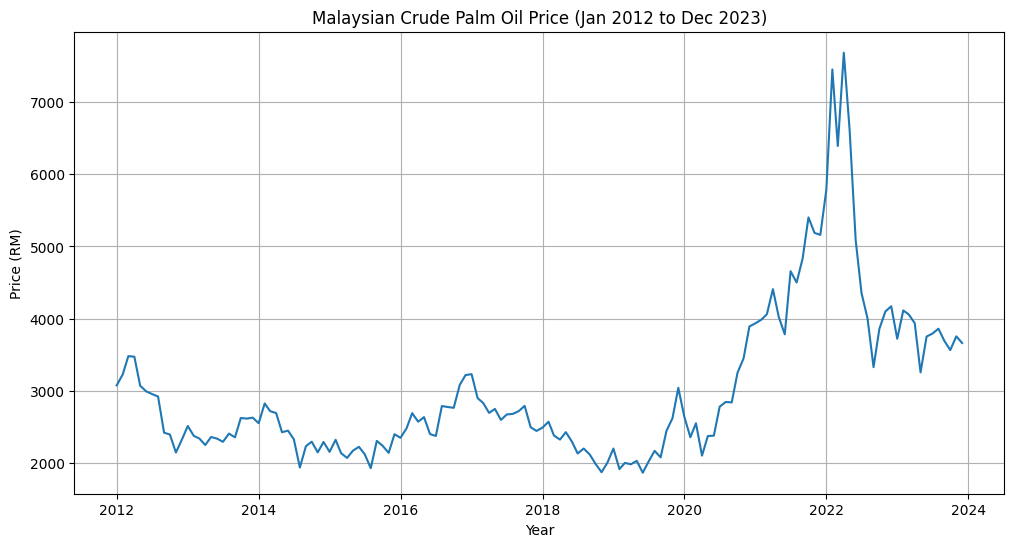

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Price'])
plt.title(f"Malaysian Crude Palm Oil Price ({data.index.min():%b %Y} to {data.index.max():%b %Y})")
plt.xlabel('Year')
plt.ylabel('Price (RM)')
plt.grid(True)
plt.show()

## 7. ARIMA Model

ARIMA building involves three steps: **tentative identification**, **parameter estimation**, and **diagnostic checking**, before forecasting can be performed. The general ARIMA(p, d, q) equation is:

$$Y_t^{D} = c + \phi_1 Y_{t-1}^{D} + \phi_2 Y_{t-2}^{D} + \dots + \phi_p Y_{t-p}^{D} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}$$

where:
- $Y_t^{D}$ = closing price at time $t$ (after differencing)
- $c$ = constant term
- $\phi_i,\ i = 1, 2, \dots, p$ = AR (autoregressive) parameters
- $\theta_i,\ i = 1, 2, \dots, q$ = MA (moving average) parameters
- $\varepsilon_t$ = error term at time $t$
- $D$ = order of differencing

### 7.1 Stationarity Testing (Augmented Dickey-Fuller Test)

ADF test refers to the Augmented Dickey-Fuller test, which is used in time series analysis (such as ARIMA) to check whether the data is stationary or not.

- Stationary data = mean and variance are constant over time → suitable for ARIMA  
- Non-stationary data = trend or changing mean over time → must be differenced before applying ARIMA  

### What ADF test gives:
- ADF statistic  
- p-value  

### Decision rule:
- If p-value ≤ 0.05 → data is stationary  
- If p-value > 0.05 → data is not stationary  

In [9]:
adf_result = adfuller(train_data['Price'])
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
criticals = adf_result[4]
for key, value in criticals.items():
    print(f'{key}: {value}')

# p-value is greater than 0.05. Thus, data is not stationary and differencing is required.

ADF Statistic: 0.062030442510534245
p-value: 0.9633710603136147
1%: -3.4924012594942333
5%: -2.8886968193364835
10%: -2.5812552709190673


### 7.2 ACF and PACF plots (Before Differencing)

#### **ACF and PACF**

ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) are tools used in time series analysis, especially for identifying the appropriate parameters in ARIMA models.

#### **ACF (Autocorrelation Function)**
ACF measures the correlation between a time series and its lagged values (past observations).  
It helps to identify how past values influence the current value over different time lags.

#### **PACF (Partial Autocorrelation Function)**
PACF measures the correlation between a time series and its lagged values after removing the effects of intermediate lags.  
It shows the direct relationship between observations at different lags.

#### In ARIMA modeling:
- ACF helps identify MA(q)
- PACF helps identify AR(p)
- Differencing order (d)
- Together, they are used to select the best ARIMA model structure

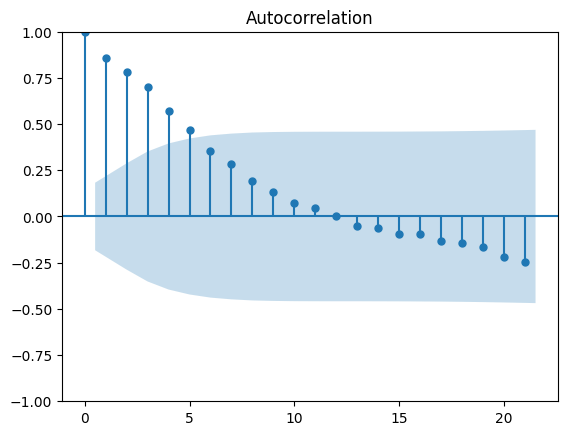

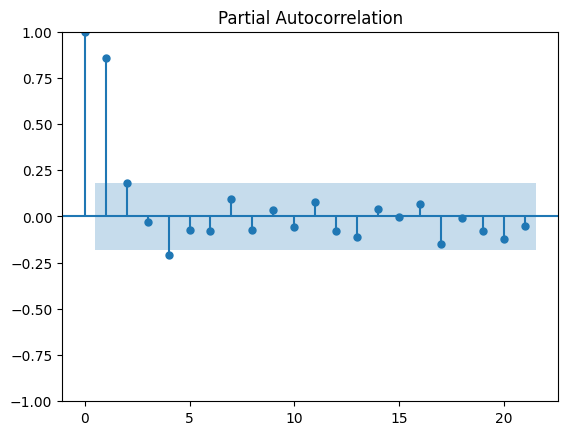

In [10]:
acf = plot_acf(train_data['Price'])
pacf = plot_pacf(train_data['Price'])
plt.show()

### 7.3 First Differencing

Since the series is non-stationary, first-order differencing is applied, and the ADF test is repeated to confirm stationarity has been achieved.

In [11]:
train_data_diff = train_data['Price'].diff().dropna()

# ADF test after differencing
adf_result_diff = adfuller(train_data_diff)
print('ADF Statistic (Differenced):', adf_result_diff[0])
print('p-value (Differenced):', adf_result_diff[1])

ADF Statistic (Differenced): -3.6460933152580886
p-value (Differenced): 0.004938560614403195


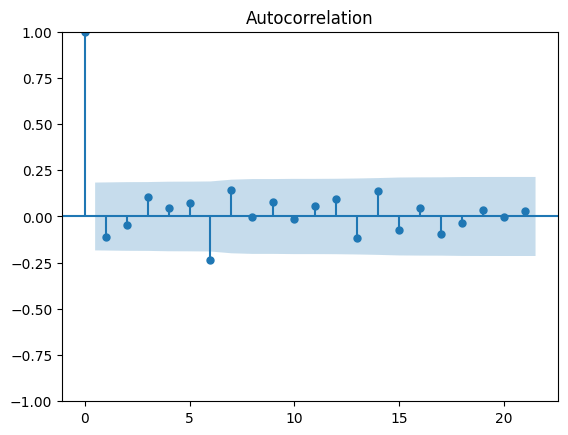

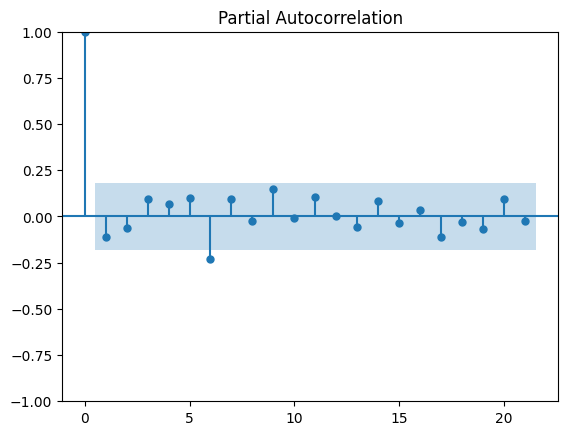

In [12]:
acf_diff = plot_acf(train_data_diff)
pacf_diff = plot_pacf(train_data_diff)
plt.show()

Based on the Augmented Dickey-Fuller (ADF) test results, the palm oil price series is non-stationary at level form, as the p-value is greater than 0.05. This indicates the presence of a unit root in the original data.

After first differencing, the series becomes stationary, as p-value is less than 0.05.

Therefore, the first-differenced series is suitable for ARIMA modelling, confirming that differencing is required to achieve stationarity before model estimation.

| Data                 | ADF Statistic | p-value        | Decision |
|----------------------|--------------|----------------|----------|
| Before differencing  | 0.062      | 0.9634         | Non-stationary (unit root exists) |
| After 1 differencing | -3.646      | 0.0049       | Stationary (no unit root) |

### 7.4 Model Selection with `auto_arima`

The `auto_arima` function automatically searches across candidate ARIMA orders and selects the model with the lowest **AIC** (Akaike Information Criterion).

In [13]:
auto_arima = pm.auto_arima(train_data['Price'], d=1, trace=True, approximation=False, stepwise= False )
auto_arima.summary()

 ARIMA(0,1,0)(0,0,0)[1] intercept   : AIC=1550.771, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[1] intercept   : AIC=1551.143, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[1] intercept   : AIC=1553.133, Time=0.19 sec
 ARIMA(0,1,3)(0,0,0)[1] intercept   : AIC=1550.932, Time=0.16 sec
 ARIMA(0,1,4)(0,0,0)[1] intercept   : AIC=1552.350, Time=0.25 sec
 ARIMA(0,1,5)(0,0,0)[1] intercept   : AIC=1554.365, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[1] intercept   : AIC=1551.257, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[1] intercept   : AIC=1553.140, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[1] intercept   : AIC=1551.703, Time=0.25 sec
 ARIMA(1,1,3)(0,0,0)[1] intercept   : AIC=1551.875, Time=0.22 sec
 ARIMA(1,1,4)(0,0,0)[1] intercept   : AIC=1553.248, Time=0.20 sec
 ARIMA(2,1,0)(0,0,0)[1] intercept   : AIC=1552.915, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[1] intercept   : AIC=1550.841, Time=0.22 sec
 ARIMA(2,1,2)(0,0,0)[1] intercept   : AIC=1551.614, Time=0.16 sec
 ARIMA(2,1,3)(0,0,0)[1] intercept   : AIC=1553.390, Time=0.21 sec
 ARIMA(3,1

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  115
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -773.385
Date:                Fri, 19 Jun 2026   AIC                           1550.771
Time:                        15:34:05   BIC                           1556.243
Sample:                    01-01-2012   HQIC                          1552.992
                         - 07-01-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.8684     20.645      0.672      0.502     -26.596      54.333
sigma2      4.572e+04   4724.368      9.677      0.000    3.65e+04     5.5e+04
===================================================================================
Ljung-Box (L1) (Q):                   1.42   Jarque-Bera (JB):                14.50
Prob(Q):                              0.23   Prob(JB):                         0.00
Heteroskedasticity (H):               2.10   Skew:                             0.45
Prob(H) (two-sided):                  0.03   Kurtosis:                         4.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The **ARIMA(0,1,0)** model has an lowest AIC value, indicating a best model fit for the data. The Ljung-Box test shows a high p-value, suggesting that there is no significant autocorrelation in the residuals. Overall, the model is suitable for capturing the structure of the time series.

### 7.5 Forecasting


1.   Non-Iterative Forecasting

2.   Rolling forecasting




#### 7.5.1 Non-Iterative Forecasting

In [14]:
forecast_test_auto = auto_arima.predict(n_periods=len(test_data))
print(forecast_test_auto)

2021-08-01    4669.868421
2021-09-01    4683.736842
2021-10-01    4697.605263
2021-11-01    4711.473684
2021-12-01    4725.342105
2022-01-01    4739.210526
2022-02-01    4753.078947
2022-03-01    4766.947368
2022-04-01    4780.815789
2022-05-01    4794.684211
2022-06-01    4808.552632
2022-07-01    4822.421053
2022-08-01    4836.289474
2022-09-01    4850.157895
2022-10-01    4864.026316
2022-11-01    4877.894737
2022-12-01    4891.763158
2023-01-01    4905.631579
2023-02-01    4919.500000
2023-03-01    4933.368421
2023-04-01    4947.236842
2023-05-01    4961.105263
2023-06-01    4974.973684
2023-07-01    4988.842105
2023-08-01    5002.710526
2023-09-01    5016.578947
2023-10-01    5030.447368
2023-11-01    5044.315789
2023-12-01    5058.184211
Freq: MS, dtype: float64


In [15]:
# Calculate RMSE and MAPE for the static (non-iterative) forecast
mape = mean_absolute_percentage_error(test_data['Price'], forecast_test_auto) * 100
rmse = np.sqrt(mean_squared_error(test_data['Price'], forecast_test_auto))
print('MAPE:', mape)
print('RMSE:', rmse)

MAPE: 24.901163592366427
RMSE: 1281.7840810330438


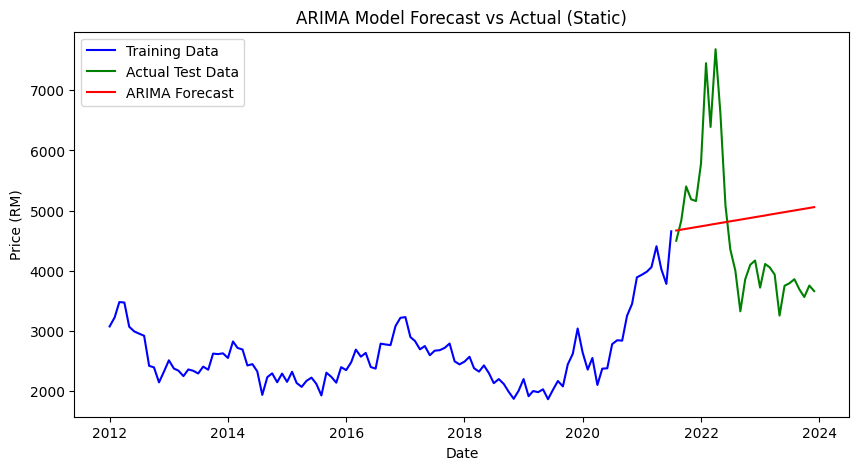

In [16]:
# Plot the static ARIMA forecast
plt.figure(figsize=(10, 5))
plt.plot(train_data.index, train_data['Price'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['Price'], label='Actual Test Data', color='green')
plt.plot(test_data.index, forecast_test_auto, label='ARIMA Forecast', color='red')
plt.title('ARIMA Model Forecast vs Actual (Static)')
plt.xlabel('Date')
plt.ylabel('Price (RM)')
plt.legend()
plt.show()

Based on the plot, red line represents the forecasted prices based on the ARIMA(4,1,0) model. The ARIMA-based forecast shows an almost flat pattern and is unable to capture price fluctuations observed in the actual prices because the data is not updated at each iteration.

#### 7.5.2 Rolling Forecast

To improve accuracy, a **rolling forecast** is implemented.

In [17]:
rolling_predictions = []
n_test = len(test_data)
for i in range(n_test):
    rolling_train = pd.concat([train_data['Price'], test_data['Price'].iloc[:i]])
    model = pm.auto_arima(rolling_train, trace=False, stepwise=True)
    next_forecast = model.predict(n_periods=1)
    rolling_predictions.append(next_forecast.item())

In [18]:
# Calculate RMSE and MAPE for the rolling forecast
rolling_rmse = np.sqrt(mean_squared_error(test_data['Price'], rolling_predictions))
rolling_mape = mean_absolute_percentage_error(test_data['Price'], rolling_predictions) * 100
print('Rolling Forecast RMSE:', rolling_rmse)
print('Rolling Forecast MAPE:', rolling_mape)

Rolling Forecast RMSE: 768.2769866571567
Rolling Forecast MAPE: 10.814359319385938


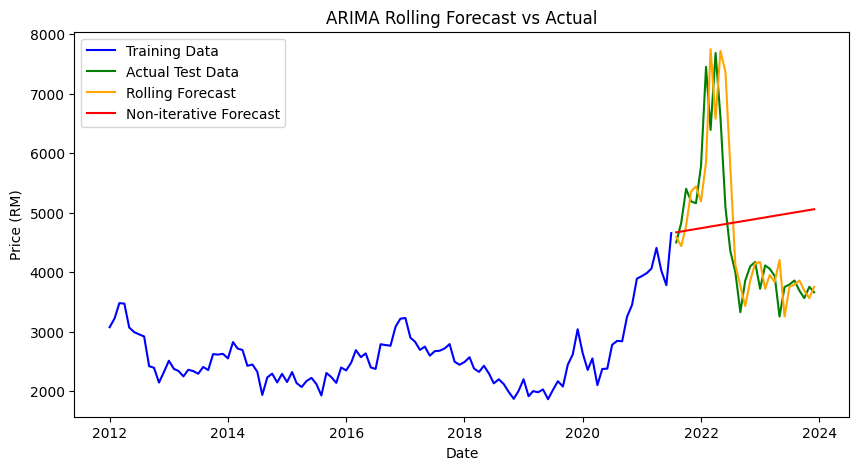

In [19]:
# Plot the rolling ARIMA forecast
plt.figure(figsize=(10, 5))
plt.plot(train_data.index, train_data['Price'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['Price'], label='Actual Test Data', color='green')
plt.plot(test_data.index, rolling_predictions, label='Rolling Forecast', color='orange')
plt.plot(test_data.index, forecast_test_auto, label='Non-iterative Forecast', color='red')
plt.title('ARIMA Rolling Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (RM)')
plt.legend()
plt.show()

Based on the plot and table below, shows that results obtained using the rolling forecast method are more accurate. This indicates that iterative forecasting (rolling forecast) is better able to capture changes in prices.

| ARIMA(4,1,0) Model | RMSE    | MAPE   |
| ------------------ | ------- | ------ |
| Non-Iterative      | 1281.78 | 24.90 |
| Rolling Forecast   | 768.28  | 10.81 |



In [20]:
# Save ARIMA rolling forecast for later comparison with LSTM
rolling_predictions_series = pd.Series(rolling_predictions, index=test_data.index)
rolling_predictions_series.to_csv('arima_predictions.csv')

## 8. LSTM Model

An LSTM (Long Short-Term Memory) network is a type of recurrent neural network designed to learn long-range dependencies in sequential data. Each LSTM unit (cell) maintains a **cell state** and a **hidden state**, regulated by three gates:

- **Forget gate** — decides what information from the cell state should be discarded, via a sigmoid layer that outputs a value between 0 and 1 based on the previous hidden state and the current input.
- **Input gate** — decides what new information should be added to the cell state.
- **Output gate** — decides what part of the cell state should be output as the new hidden state.
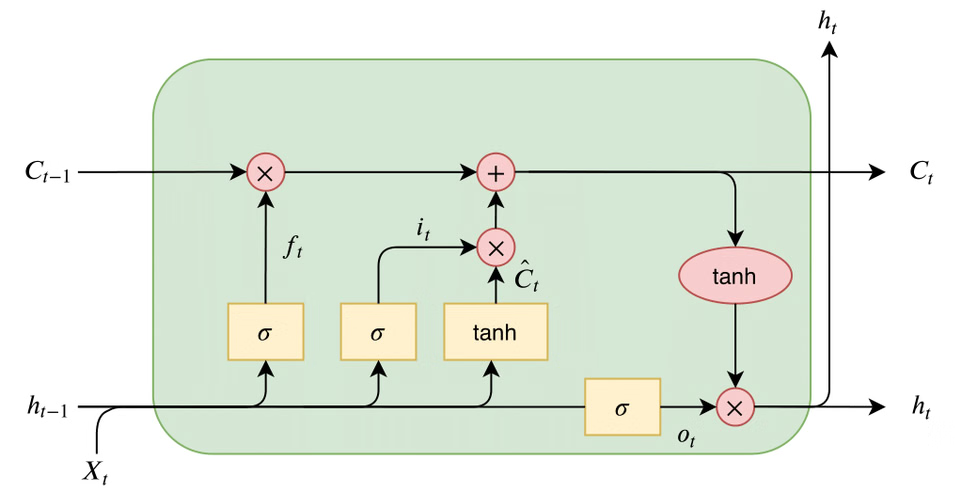

### 8.1 Setup

In [21]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

### 8.2 Data Normalisation

Neural networks train more effectively on data scaled to a small, consistent range. A `MinMaxScaler` is fitted on the **training data only** and used to rescale prices to the range [0, 1].

In [22]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_data = scaler.fit_transform(train_data[['Price']])
scaled_test_data = scaler.transform(test_data[['Price']])

### 8.3 Sequence Creation

LSTMs learn from fixed-length sequences ("sliding windows") of past observations to predict the next value. In this study, a window of **12 months** is used. Each training example uses the previous 12 monthly prices to predict the 13th.

In [23]:
# Create sequences for LSTM
def create_sequences(data, seq_length=12):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(x), np.array(y)

seq_length = 12
x_train, y_train = create_sequences(scaled_train_data, seq_length)
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

### 8.4 Building and Training the Model

Four layers are used in the construction of this model, namely a bidirectional LSTM layer, a dropout layer, an LSTM layer, and a dense layer. The output shape is represented as (batch size, time steps, number of neurons). A detailed explanation of each layer is provided below.

#### i. **Bidirectional LSTM Layer**
The bidirectional LSTM layer consists of two LSTM components, where the first LSTM processes the input data in the backward direction while the second LSTM processes the input data in the forward direction. The purpose of this layer is to help the model make better predictions by capturing information from both directions.

#### ii. **Dropout Layer**  
The function of the dropout layer in this model is to reduce overfitting and prevent the model from relying too heavily on specific neurons. The dropout rate is set at 20% with 100 neurons.

#### iii. **LSTM Layer**  
The LSTM layer is designed to refine the output from the bidirectional LSTM layer and further process it by reducing the number of neurons from 100 to 50. This helps to reduce excessive input complexity and prevent overfitting.

#### iv. **Dense Layer**  
The dense layer connects the output from the LSTM layer to the final output using one neuron and an activation function.


---
In addition, a hyperparameter tuning process is performed to identify the optimal combination of epochs and batch size based on validation MAPE. Early stopping is employed to reduce overfitting and automatically restore the best model weights.

In [24]:

# Hyperparameter tuning for LSTM

from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

split = int(len(x_train) * 0.8)

x_train_sub = x_train[:split]
y_train_sub = y_train[:split]

x_val = x_train[split:]
y_val = y_train[split:]

epoch_list = [20, 50, 100]
batch_list = [8, 16, 32]

results = []

for epochs in epoch_list:
    for batch_size in batch_list:

        temp_model = Sequential([
            Bidirectional(LSTM(32, return_sequences=True),
                          input_shape=(seq_length,1)),
            Dropout(0.2),
            LSTM(32),
            Dense(1)
        ])

        temp_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss=tf.keras.losses.Huber()
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        temp_model.fit(
            x_train_sub,
            y_train_sub,
            validation_data=(x_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=[early_stop]
        )

        pred = temp_model.predict(x_val, verbose=0)

        mape = mean_absolute_percentage_error(y_val, pred) * 100

        results.append([epochs, batch_size, mape])

results_df = pd.DataFrame(
    results,
    columns=['Epochs', 'Batch Size', 'Validation MAPE']
)

results_df = results_df.sort_values('Validation MAPE')
display(results_df)

best_epochs = int(results_df.iloc[0]['Epochs'])
best_batch = int(results_df.iloc[0]['Batch Size'])

print(f"Best Epochs: {best_epochs}")
print(f"Best Batch Size: {best_batch}")

# Final LSTM Model
model = Sequential([
    Bidirectional(LSTM(32, return_sequences=True),
                  input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber()
)

early_stop = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

model.fit(
    x_train,
    y_train,
    epochs=best_epochs,
    batch_size=best_batch,
    verbose=2,
    callbacks=[early_stop]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `

,Epochs,Batch Size,Validation MAPE
6,100,8,36.055159
3,50,8,36.264256
0,20,8,36.587566
1,20,16,37.571583
7,100,16,37.718235
8,100,32,43.140109
2,20,32,43.554749
4,50,16,44.018040
5,50,32,44.778766


Best Epochs: 100
Best Batch Size: 8
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 - 4s - 338ms/step - loss: 0.0180
Epoch 2/100
13/13 - 0s - 24ms/step - loss: 0.0094
Epoch 3/100
13/13 - 0s - 23ms/step - loss: 0.0076
Epoch 4/100
13/13 - 0s - 21ms/step - loss: 0.0062
Epoch 5/100
13/13 - 0s - 22ms/step - loss: 0.0058
Epoch 6/100
13/13 - 0s - 22ms/step - loss: 0.0047
Epoch 7/100
13/13 - 0s - 22ms/step - loss: 0.0048
Epoch 8/100
13/13 - 0s - 20ms/step - loss: 0.0043
Epoch 9/100
13/13 - 0s - 17ms/step - loss: 0.0042
Epoch 10/100
13/13 - 0s - 14ms/step - loss: 0.0040
Epoch 11/100
13/13 - 0s - 13ms/step - loss: 0.0039
Epoch 12/100
13/13 - 0s - 12ms/step - loss: 0.0041
Epoch 13/100
13/13 - 0s - 12ms/step - loss: 0.0041
Epoch 14/100
13/13 - 0s - 12ms/step - loss: 0.0039
Epoch 15/100
13/13 - 0s - 12ms/step - loss: 0.0039
Epoch 16/100
13/13 - 0s - 12ms/step - loss: 0.0040
Epoch 17/100
13/13 - 0s - 14ms/step - loss: 0.0037
Epoch 18/100
13/13 - 0s - 12ms/step - loss: 0.0037
Epoch 19/100
13/13 - 0s - 13ms/step - loss: 0.0039
Epoch 20/100
13/13 - 0s - 12ms/step - loss: 0.0039


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_9 (Bidirectional) │ (None, 12, 64)         │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,461 (247.90 KB)

 Trainable params: 21,153 (82.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 42,308 (165.27 KB)

### 8.5 Forecasting

### 8.5.1 Non-Iterative Forecast

In [25]:
# Forecast 2023 prices
prediction = []
last_sequence = scaled_train_data[-seq_length:]

for i in range(len(test_data)):
    last_sequence = last_sequence.reshape((1, seq_length, 1))
    predicted_pricess = model.predict(last_sequence, verbose=0)
    prediction.append(predicted_pricess[0][0])
    last_sequence = np.append(last_sequence[:, 1:, :], predicted_pricess.reshape((1, 1, 1)), axis=1)

predicted_pri = scaler.inverse_transform(np.array(prediction).reshape(-1, 1)).flatten()

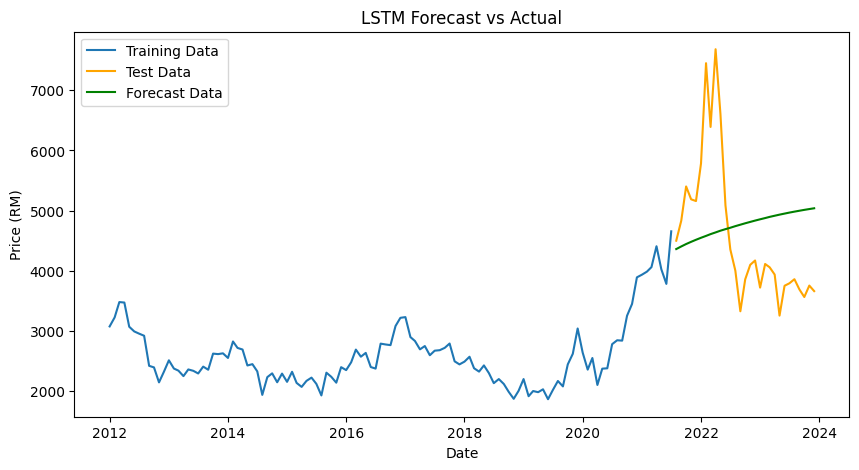

In [26]:
# @title
plt.figure(figsize=(10, 5))
plt.plot(train_data.index, train_data['Price'], label='Training Data')
plt.plot(test_data.index, test_data['Price'], label='Test Data', color='orange')
plt.plot(test_data.index, predicted_pri, label='Forecast Data', color='green')
plt.xlabel('Date')
plt.ylabel('Price (RM)')
plt.title('LSTM Forecast vs Actual')
plt.legend()
plt.show()

In [27]:
# Calculate RMSE and MAPE for the static (non-iterative) LSTM forecast
mape = mean_absolute_percentage_error(test_data['Price'], predicted_pri) * 100
rmse = np.sqrt(mean_squared_error(test_data['Price'], predicted_pri))
print(f'MAPE: {mape}')
print(f'RMSE: {rmse}')

MAPE: 25.297991372194563
RMSE: 1319.5681899116114


Based on table and graph, the difference between the actual prices and the forecasted prices is very significant. Thus, forecasted prices using the LSTM model without the iterative method appear relatively flat and fail to capture the movements in the actual prices.

### 8.5.2 Rolling forecast

In [28]:
# @title
# Rolling forecast
predictions = []
last_sequence = scaled_train_data[-seq_length:]
actual_prices = test_data['Price'].values

for i in range(len(test_data)):
    # Reshape last sequence and make a prediction
    last_sequence = last_sequence.reshape((1, seq_length, 1))
    predicted_price = model.predict(last_sequence, verbose=0)

    # Store the prediction
    predictions.append(predicted_price[0][0])

    # Update last sequence with the actual test data point for rolling forecast
    actual_scaled = scaler.transform(np.array([[actual_prices[i]]]))
    last_sequence = np.append(last_sequence[:, 1:, :], actual_scaled.reshape((1, 1, 1)), axis=1)

# Inverse transform the predicted prices
predicted_prices = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

In [29]:
# Calculate RMSE and MAPE for the rolling LSTM forecast
mape = mean_absolute_percentage_error(actual_prices, predicted_prices) * 100
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f'MAPE: {mape}')
print(f'RMSE: {rmse}')

MAPE: 10.433664364214701
RMSE: 744.0215601935283


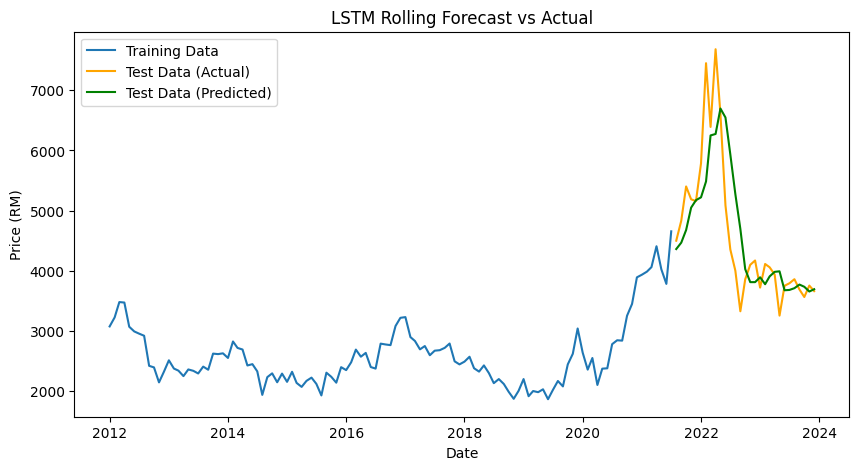

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(train_data.index, train_data['Price'], label='Training Data')
plt.plot(test_data.index, test_data['Price'], label='Test Data (Actual)', color='orange')
plt.plot(test_data.index, predicted_prices, label='Test Data (Predicted)', color='green')
plt.xlabel('Date')
plt.ylabel('Price (RM)')
plt.title('LSTM Rolling Forecast vs Actual')
plt.legend()
plt.show()

Above graph shows that rolling forecast results using the LSTM model with a batch size of 16 and 20 epochs with the iterative method. The LSTM forecast results exhibit a pattern that closely follows the actual prices, with price movements that are more aligned with the actual values.

## 9. Model Comparison

Forecast accuracy is compared using:

$$\text{MAPE} = \frac{1}{n} \sum_{t=1}^{n} \left| \frac{Y_t - \hat{Y}_t}{Y_t} \right| \times 100\%, \qquad \text{RMSE} = \sqrt{\frac{1}{n} \sum_{t=1}^{n} \left(Y_t - \hat{Y}_t \right)^2}$$

where $n$ is the sample size, $Y_t$ is the observed value, and $\hat{Y}_t$ is the forecast value. Lower values indicate a more accurate model.

In the thesis, the rolling-forecast results were:

| Model | RMSE | MAPE |
|---|---|---|
| ARIMA(0,1,0) | 768.28 | 10.81% |
| LSTM | 744.02 | 10.43% |

Both models achieved a MAPE below 10–11%, which according to Walker et al. (2020) indicates reasonably accurate forecasts. However, **LSTM outperformed ARIMA** with lower RMSE and MAPE.

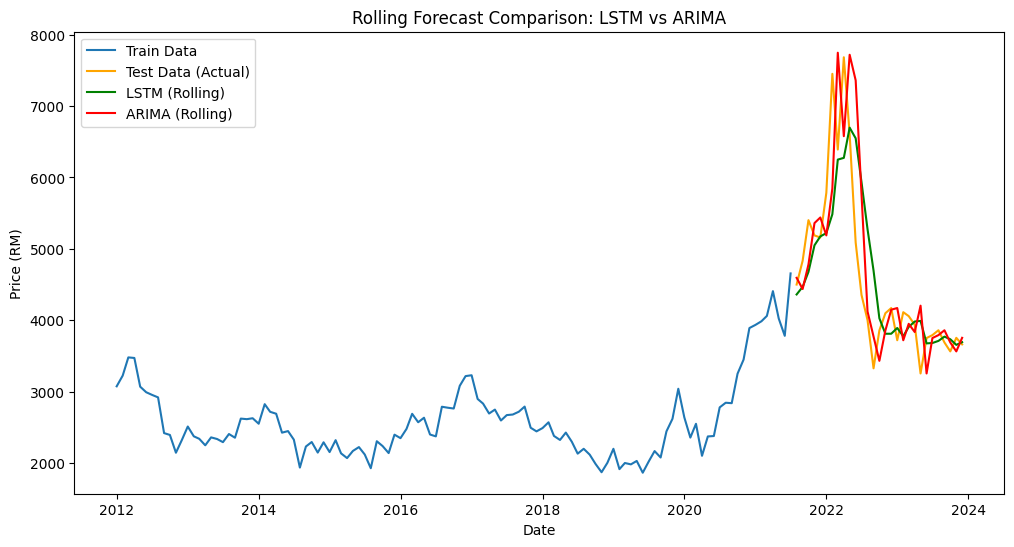

In [31]:
arima_predictions = pd.read_csv('arima_predictions.csv', index_col=0)

plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Price'], label='Train Data')
plt.plot(test_data.index, test_data['Price'], label='Test Data (Actual)', color='orange')
plt.plot(test_data.index, predicted_prices, label='LSTM (Rolling)', color='green')
plt.plot(test_data.index, arima_predictions, label='ARIMA (Rolling)', color='red')
plt.xlabel('Date')
plt.ylabel('Price (RM)')
plt.title('Rolling Forecast Comparison: LSTM vs ARIMA')
plt.legend()
plt.show()

## 10. Conclusion

Building the ARIMA model involved tentative identification, parameter estimation, and diagnostic checking before forecasting. The LSTM model was built using a Bidirectional LSTM layer, a Dropout layer, an LSTM layer, and a Dense layer, trained with a batch size of 16 over 20 epochs. To improve forecast accuracy, a rolling (iterative) forecast method was implemented and compared against the static (non-iterative) method for both models. Forecast accuracy was evaluated using RMSE and MAPE, and the best-performing model was identified.

In this study, the LSTM model also outperformed the ARIMA model based on both RMSE and MAPE results. However, it should be noted that the difference in forecasting accuracy between the ARIMA and LSTM models is relatively small. This may be due to the limited size of the dataset, as LSTM models generally perform better when trained on larger amounts of data. In addition, the forecasting results may not be highly accurate in real-world situations because the models only use historical price data and do not consider other factors that can affect palm oil prices, such as economic conditions, supply and demand changes, government policies, and global market events.

## References

1. Siami-Namini, S., Tavakoli, N. & Namin, A.S. 2018. A comparison of ARIMA and LSTM in forecasting time series. *17th IEEE International Conference on Machine Learning and Applications (ICMLA)*, 1394–1401. IEEE.
2. Yee, K.F. & Samsudin, H.B. 2021.Comparison between Artificial Neural Network and ARIMA Model in Forecasting Palm Oil Price in Malaysia. International Journal of Scientific Engineering and Science 5(11): 12-15.
3. Hamid, M.F.A. & Shabri, A. 2017. Palm Oil Price Forecasting Model: An Autoregressive Distributed Lag (ARDL) Approach. AIP Conference Proceedings 1842.
4. Isa, M. A., Baharim, A. T., Mohamed, S., Noh, M. K. A., Nasrul, F., Ibrahim, W. M. F. W. & Hassan, S. S. 2020). Crude palm oil price fluctuation in Malaysia. International Journal of Academic Research in Business and Social Sciences 10(5): 879-892.
5. Amal, I. 2021. Crude palm oil price prediction using multilayer perceptron and long short-term memory. J. Math. Comput. Sci. 11(6): 8034-8045.